<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-TextMining/blob/main/TextMining/ex02_%EC%83%81%ED%92%88_%EB%A6%AC%EB%B7%B0_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EA%B0%90%EC%84%B1_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# 작업 경로 변경
%cd /content/drive/MyDrive/00 텍스트 마이닝

/content/drive/MyDrive/00 텍스트 마이닝


### 실습 파일 불러오기
- naver_shopping.txt 파일 df로 불러오기 -> data
- \t 으로 데이터 구분 되어있음

In [3]:
# 필요한 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 데이터 불러오기
data = pd.read_csv("./data/naver_shopping.txt", delimiter="\t", header=None)
# read_scv 함수는 맨 첫 번째 줄을 header로 인식하여 컬럼 이름으로 넣기 때문에, header가 파일에 없다는 것을 알려주어야 함

In [5]:
data

,0,1
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
...,...,...
199995,2,장마라그런가!!! 달지않아요
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요
199998,5,넘이쁘고 쎄련되보이네요~


In [6]:
# 컬럼명 업데이트
data.columns = ["평점", "리뷰"]
data.head()

,평점,리뷰
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [7]:
# 필요한 리뷰데이터만 인덱싱
text = data["리뷰"]

### 텍스트 데이터 전처리
1. 결측치 확인
2. 특수문자 제거

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   평점      200000 non-null  int64 
 1   리뷰      200000 non-null  object
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [9]:
# re 모듈을 활용해 특수문자를 제거
import re # 정규 표현식을 사용하기 위한 모듈

| 특수 문자        | 설명                                                                 |
|------------------|----------------------------------------------------------------------|
| `.`              | 한 개의 임의의 문자 (단, 줄바꿈 문자 `\n` 제외)                       |
| `?`              | 앞의 문자가 **있을 수도, 없을 수도** 있음 (0개 또는 1개)             |
| `*`              | 앞의 문자가 **0개 이상** 반복됨                                       |
| `+`              | 앞의 문자가 **1개 이상** 반복됨                                       |
| `^`              | **문자열의 시작**을 의미                                              |
| `$`              | **문자열의 끝**을 의미                                                |
| `{숫자}`         | 정확히 해당 **숫자만큼 반복**함                                       |
| `{숫자1, 숫자2}` | **숫자1 이상 숫자2 이하** 만큼 반복함                                 |
| `{숫자,}`        | **숫자 이상** 반복함                                                  |
| `[...]`          | 대괄호 안의 문자들 중 **하나**와 매치. 예: `[abc]` → a 또는 b 또는 c |
| `[a-z]`          | **소문자 알파벳 범위**와 매치                                         |
| `[a-zA-Z]`       | **모든 알파벳**과 매치                                                |
| `[^문자]`        | **해당 문자를 제외한 문자**와 매치                                    |


In [10]:
# 전화번호 검출
# 추출하고 싶은 전화번호의 형태를 생각해보자!
# 010-1234-5678, 01012345678, 010-12345678
# 중간에 하이픈이 있거나 없거나 하는 모든 패턴을 검출해보자!

# 정규 표현식을 사용해 규칙 생성
p = re.compile("010-?[0-9]{4}-?[0-9]{4}")
# ? : 앞에 있는 문자가 있을 수도 없을 수도 있다!(1 or 0개)
# [] : 대괄호 안의 문자 하나와 매칭
# {숫자} : 앞에 있는 문자가 숫자만큼 반복

In [11]:
# 생성한 규칙을 가지고 문자 패턴 검색
result = p.search("내 전화번호는 010-1234-5678이야!")
# match : 정해진 규칙과 일치하는 부분
# span = (시작점, 끝점 +1)
str1 = "내 전화번호는 010-1234-5678이야!"
str1[8:21]

'010-1234-5678'

In [12]:
result.start
result.end
# 바로 슬라이싱에 활용 가능

<function Match.end(group=0, /)>

In [13]:
# 리뷰 데이터에 특수문자 제거!
# 패턴 저장
pattern = r"[^a-zA-z0-9가-힣\s\.\?\!]"

# [^] : not
# a-z : 영어 소문자
# A-z : 영어 대문자
# 0-9 : 숫자
# 가-힣 : 한글
# \s : 띄어쓰기, \. : 온점, \? : 물음표, \! : 느낌표


In [14]:
# 반복문을 통해 데이터에 모두 패턴 적용
from tqdm import tqdm

new_doc = []
for doc in tqdm(text) :
  clean_doc = re.sub(pattern, "", doc) # 해당 패턴에 해당하는 부분을 삭제
  new_doc.append(clean_doc)

100%|██████████| 200000/200000 [00:00<00:00, 444579.60it/s]


In [15]:
# 정제된 텍스트 데이터를 새로운 컬럼으로 추가
data["cleaned_doc"] = new_doc

In [16]:
data.head()
# 감성 분석인데 ㅎㅎ를 왜 삭제하는 거지...?

,평점,리뷰,cleaned_doc
0,5,배공빠르고 굿,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요


### 이모지 제거

In [17]:
# 필요한 패키지 설치
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.7 MB/s eta 0:00:00


In [18]:
temp = 'DM으로 연락바랍니다 🙏🙏 😊🤣😍'

In [19]:
import emoji

In [20]:
# 이모지 -> 텍스트 변환
emoji.demojize(temp)
# 이모지를 해석해서 문자열로 변환

'DM으로 연락바랍니다 :folded_hands::folded_hands: :smiling_face_with_smiling_eyes::rolling_on_the_floor_laughing::smiling_face_with_heart-eyes:'

In [21]:
# 이모지 삭제
emoji.replace_emoji(temp).strip() # strip() : 뒤에 남은 띄어쓰기 제거

'DM으로 연락바랍니다'

### 형태소 분리
- 형태소 분리, 어간추출, 정규화, 원하는 품사 추출, 불용어 제거, 띄어쓰기 교정
- DF 새로운 컬럼으로 추가

In [22]:
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 76.5 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=59aa96a1130f9852d8f3407365f85ed210c32f2c77b537ade52a7176a40be7bf
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


In [23]:
# 불용어 사전 로드
from kiwipiepy.utils import Stopwords
# 불용어 : 텍스트 데이터에 자주 등장을 하지만 의미 파악에 크게 상관이 없는 단어

In [25]:
# 불용어 사전 객체 초기화
stopwords = Stopwords()

In [28]:
stopwords.stopwords
# 기본적으로 키위의 불용어 리스트는 단어, 품사가 들어가있는데
# 단어들만 추출

{('ᆫ', 'ETM'),
 ('ᆫ', 'JX'),
 ('ᆫ다', 'EF'),
 ('ᆯ', 'ETM'),
 ('가', 'JKS'),
 ('같', 'VA'),
 ('것', 'NNB'),
 ('게', 'EC'),
 ('겠', 'EP'),
 ('고', 'EC'),
 ('고', 'JKQ'),
 ('과', 'JC'),
 ('과', 'JKB'),
 ('그', 'MM'),
 ('그', 'NP'),
 ('기', 'ETN'),
 ('까지', 'JX'),
 ('나', 'NP'),
 ('년', 'NNB'),
 ('는', 'ETM'),
 ('는', 'JX'),
 ('다', 'EC'),
 ('다', 'EF'),
 ('다고', 'EC'),
 ('다는', 'ETM'),
 ('대하', 'VV'),
 ('더', 'MAG'),
 ('던', 'ETM'),
 ('도', 'JX'),
 ('되', 'VV'),
 ('되', 'XSV'),
 ('들', 'XSN'),
 ('등', 'NNB'),
 ('따르', 'VV'),
 ('때', 'NNG'),
 ('때문', 'NNB'),
 ('라', 'EC'),
 ('라는', 'ETM'),
 ('로', 'JKB'),
 ('를', 'JKO'),
 ('만', 'JX'),
 ('만', 'NR'),
 ('말', 'NNG'),
 ('며', 'EC'),
 ('면', 'EC'),
 ('면서', 'EC'),
 ('명', 'NNB'),
 ('받', 'VV'),
 ('보', 'VV'),
 ('부터', 'JX'),
 ('사람', 'NNG'),
 ('성', 'XSN'),
 ('수', 'NNB'),
 ('아니', 'VCN'),
 ('않', 'VX'),
 ('어', 'EC'),
 ('어', 'EF'),
 ('어서', 'EC'),
 ('어야', 'EC'),
 ('없', 'VA'),
 ('었', 'EP'),
 ('에', 'JKB'),
 ('에게', 'JKB'),
 ('에서', 'JKB'),
 ('와', 'JC'),
 ('와', 'JKB'),
 ('우리', 'NP'),
 ('원', 'NNB'),


In [31]:
stopwords_list = [word for word, tag in stopwords.stopwords]
stopwords_list

['원',
 '중',
 '그',
 '대하',
 '이',
 '주',
 '이',
 '부터',
 '며',
 'ᆫ',
 '더',
 '되',
 '이',
 '받',
 '는',
 '면',
 '에',
 '일',
 '까지',
 '때문',
 '와',
 '가',
 '성',
 '지역',
 '나',
 '들',
 '다',
 '는',
 '않',
 '고',
 '과',
 '통하',
 '되',
 '기',
 '화',
 '다고',
 '없',
 '으로',
 '을',
 '겠',
 '일',
 '같',
 '명',
 '있',
 '어야',
 '있',
 '에게',
 '로',
 '것',
 '어서',
 '만',
 '을',
 '다',
 '하',
 '고',
 '어',
 '등',
 '따르',
 '라',
 '하',
 '면서',
 '라는',
 '의',
 '지만',
 '제',
 '었',
 '말',
 '적',
 '이',
 '은',
 '위하',
 '월',
 '때',
 'ᆫ다',
 '만',
 '년',
 '던',
 '보',
 '에서',
 'ᆯ',
 '어',
 '이',
 '를',
 '와',
 '수',
 '은',
 '게',
 '도',
 'ᆫ',
 '하',
 '지',
 '우리',
 '과',
 '하',
 '지',
 '한',
 '다는',
 '그',
 '아니',
 '사람']

In [ ]:
# 이번 실습
# kiwi -> 불용어 리스트 제공, 띄어쓰기 교정
# okt -> 형태소 분석

In [32]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 27.2 MB/s eta 0:00:00


In [34]:
# 형태소 분석기 객체 초기화
from konlpy.tag import Okt
from kiwipiepy import Kiwi

okt = Okt()
kiwi = Kiwi()

In [36]:
# 띄어쓰기 교정, 원하는 품사 필터링, 형태소 분석할 수 있는 함수 정의
def pos_tagging(text) :
  # 1. 띄어쓰기 교정
  text = kiwi.space(text)

  # 2. 품사 태깅(형태소 분리) -> 어간 추출, 정규화
  pos_words = okt.pos(
      text,
      stem = True, # 어간추출
      norm = True # 표현 정규화
  )

  # 3. 원하는 품사만 추출 (명사, 형용사, 동사)
  # + 불용어 리스트에 해당하지 않는지도 확인
  tagged_list = []

  for word, tag in pos_words :
    if tag in ["Noun", "Adjective", "Verb"] :
      if word not in stopwords_list :
        tagged_list.append(word)
  return tagged_list

In [37]:
# 함수 작동 테스트
pos_tagging(data["cleaned_doc"].iloc[1])

['택배', '엉망', '용', '저희', '집', '밑', '층', '놔두다', '가다']

In [38]:
# 전체 데이터에 적용
tagged_doc = []
for text in tqdm(data["cleaned_doc"]) : # 모든 리뷰들을 순회
  tagged_doc.append(pos_tagging(text)) # 형태소 분리 및 전처리된 text들

100%|██████████| 200000/200000 [25:52<00:00, 128.80it/s]


In [39]:
# df에 컬럼으로 추가
data["tagged_doc"] = tagged_doc

In [41]:
# 전처리가 완료된 데이터를 따로 저장
import pickle

with open("./data/naver_shopping(정제 및 토큰화 완료).pkl", "wb") as f :
  pickle.dump(data, f)
# with를 활용하면 파일의 open 및 close를 한 번에 처리 가능

In [ ]:
# 전처리 과정이 매우 오래 걸렸기 때문에 현재까지 결과를 한 번 저장해서
# 바로 불러올 수 있도록 하기
# pickle은 파이썬 객체 그대로 저장 가능
# 속도도 더 빠름, 객체 그대로 저장 가능하기 때문에 자주 활용

### 정제 및 토큰화 완료!
- 다음 실습부터는 아래부터 실행!!

In [2]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 작업 경로 변경
%cd /content/drive/MyDrive/00 텍스트 마이닝

/content/drive/MyDrive/00 텍스트 마이닝


In [ ]:
!pip install gensim
# 임베딩 관련 기능을 제공해주는 패키지

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.6 MB/s eta 0:00:00


In [ ]:
!apt-get install -y fonts-nanum*
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 2 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0 

In [4]:
# pkl 파일 불러오기
import pandas as pd
import pickle
from tqdm import tqdm

with open("./data/naver_shopping(정제 및 토큰화 완료).pkl", "rb") as f :
  data = pickle.load(f)

In [43]:
data

,평점,리뷰,cleaned_doc,tagged_doc
0,5,배공빠르고 굿,배공빠르고 굿,"[배, 공, 빠르다, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 엉망, 용, 저희, 집, 밑, 층, 놔두다, 가다]"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[아주, 좋다, 바지, 정말, 좋다, 개, 구매, 하다, 가격, 대박, 이다, 바느..."
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 용, 받다, 전달, 하다, 하다, 상품, 이다, 머그, 컵, 오다, 당황,..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요,"[민트, 색상, 예쁘다, 옆, 손잡이, 거, 용, 도로, 사용, 되다]"
...,...,...,...,...
199995,2,장마라그런가!!! 달지않아요,장마라그런가!!! 달지않아요,"[장마, 런가, 달, 않다]"
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[다이슨, 케이스, 구매, 하다, 다이슨, 슈퍼, 소닉, 드라이기, 케이스, 구매,..."
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,로드샾에서 사는것보다 세배 저렴하네요 자주이용할께요,"[로드샾, 살다, 세, 배, 저렴하다, 자주, 이용, 하다]"
199998,5,넘이쁘고 쎄련되보이네요~,넘이쁘고 쎄련되보이네요,"[넘다, 이쁘다, 쎄다, 되다, 보이다]"


### Word2Vec
- 단어 임베딩 모델 중 하나
- 단어 임베딩 : 단어 벡터화 + 의미 반영

> 두 가지 방법
> 1. CBOW : 주변에 있는 단어들을 입력으로 중간에 있는 단어들을 학습/예측하는 방법
> 2. Skip-gram : 중간에 있는 단어들을 입력으로 주변 단어들을 학습/예측하는 방법

세션 다시 시작!

In [5]:
import gensim.downloader as api

In [6]:
# 'api.info()' 메서드를 통해 모델들의 정보를 가져와서
# 'models'라는 키 아래에 있는 항목들을 정렬하여 반복
for model_name, model_data in sorted(api.info()['models'].items()):

    # 각 모델의 데이터에서 'num_records' 키에 해당하는 값이 있으면 사용, 없으면 기본값 -1을 사용
    num_records = model_data.get('num_records', -1)

    # 각 모델의 설명을 40자까지만 잘라서 표시하고 그 뒤에 '...'을 추가
    description = model_data['description'][:40] + '...'

    # 각 모델의 이름, 레코드 수, 그리고 잘린 설명을 출력
    print(f"{model_name} ({num_records} records): {description}")

__testing_word2vec-matrix-synopsis (-1 records): [THIS IS ONLY FOR TESTING] Word vecrors ...
conceptnet-numberbatch-17-06-300 (1917247 records): ConceptNet Numberbatch consists of state...
fasttext-wiki-news-subwords-300 (999999 records): 1 million word vectors trained on Wikipe...
glove-twitter-100 (1193514 records): Pre-trained vectors based on  2B tweets,...
glove-twitter-200 (1193514 records): Pre-trained vectors based on 2B tweets, ...
glove-twitter-25 (1193514 records): Pre-trained vectors based on 2B tweets, ...
glove-twitter-50 (1193514 records): Pre-trained vectors based on 2B tweets, ...
glove-wiki-gigaword-100 (400000 records): Pre-trained vectors based on Wikipedia 2...
glove-wiki-gigaword-200 (400000 records): Pre-trained vectors based on Wikipedia 2...
glove-wiki-gigaword-300 (400000 records): Pre-trained vectors based on Wikipedia 2...
glove-wiki-gigaword-50 (400000 records): Pre-trained vectors based on Wikipedia 2...
word2vec-google-news-300 (3000000 records): Pre-trai

- Records : 레코드의 수, 즉 데이터의 개수를 의미(각 "레코드"는 임베딩된 단어 하나를 의미)

| 모델 이름                           | 레코드 수      | 설명                                                                                                  |
|-------------------------------------|----------------|-------------------------------------------------------------------------------------------------------|
| conceptnet-numberbatch-17-06-300    | 1,917,247      | ConceptNet Numberbatch는 개념 간의 관계를 학습한 모델.                                                 |
|                                     |                | 상식을 이해하고 개념 간 관계를 연결시키기 위해 개발됨.                                                 |
|                                     |                | 주로 의미 네트워크 연구에 사용됨. "고양이"와 "동물" 간의 관계를 학습.                                  |
| fasttext-wiki-news-subwords-300     | 999,999        | fastText는 단어뿐만 아니라 서브워드(단어의 작은 부분)를 학습.                                          |
|                                     |                | "unbelievable"을 "un", "believe", "able"로 나누어 학습.                                                 |
|                                     |                | Wikipedia와 뉴스 기사 데이터를 기반으로 학습됨.                                                       |
| glove-twitter-100                   | 1,193,514      | GloVe는 Stanford에서 개발된 모델로, 단어 간의 공간적 관계를 벡터로 표현.                               |
|                                     |                | 트위터 데이터(2억 개 트윗)로 학습되어 소셜 미디어 자연어 처리 작업에 적합.                             |
| word2vec-google-news-300            | 3,000,000      | Word2Vec은 구글 뉴스 데이터로 학습된 모델.                                                             |
|                                     |                | 뉴스 기사의 단어 간 유사성 및 의미적 관계를 잘 포착.                                                   |
|                                     |                | 뉴스 데이터 기반이기 때문에 자연어 처리에 많이 사용됨.                                                 |
| word2vec-ruscorpora-300             | 184,973        | Word2Vec ruscorpora는 러시아어 텍스트 기반의 모델로,                                                   |
|                                     |                | 러시아어 자연어 처리 작업에 사용됨.                                                                   |


In [8]:
# word2vec-google-news-300
# 구글 뉴스데이터로 훈련된 word2vec 모델
# 300만개의 단어 벡터를 포함하고 있으며 각 단어는 300차원의 벡터로 표현
model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


## 유사도 계산
- 유사도(Similarity) : 비슷한 정도

> 1. Euclidean Distance(유클리디안 거리)
> 2. Cosine Similarity(코사인 유사도)
> - 유클리디안 거리에서는 `거리가 가까울 수록`, 코사인 유사도에서는 `각 데이터 간의 각도가 작을 수록` 데이터가 비슷하다는 것을 의미

$ similarity=cos(Θ)=\frac{A⋅B}{||A||\ ||B||}=\frac{\sum_{i=1}^{n}{A_{i}×B_{i}}}{\sqrt{\sum_{i=1}^{n}(A_{i})^2}×\sqrt{\sum_{i=1}^{n}(B_{i})^2}} $

> **분자(위쪽 식):**  
> - $(A \cdot B)$ : 두 벡터의 내적(점곱)  
> - $(\sum_{i=1}^n A_i \times B_i$) 형태로 각 차원별 곱을 모두 더한 값  

> **분모(아래쪽 식):**  
> - $(\|A\|$)와 $(\|B\|$)는 각각 벡터 $(A$)와 $(B$)의 크기(노름, norm)  
> - $(\sqrt{\sum_{i=1}^n (A_i)^2}$)와 $(\sqrt{\sum_{i=1}^n (B_i)^2}$)로 계산  

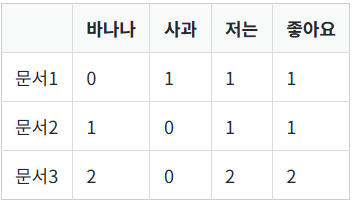

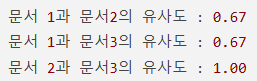

In [9]:
# "cat" 단어의 임베딩 벡터를 가져와보자!
cat_vector = model["cat"]
cat_vector
# cat 단어에 해당하는 300차원 벡터가 출력

array([ 0.0123291 ,  0.20410156, -0.28515625,  0.21679688,  0.11816406,
        0.08300781,  0.04980469, -0.00952148,  0.22070312, -0.12597656,
        0.08056641, -0.5859375 , -0.00445557, -0.296875  , -0.01312256,
       -0.08349609,  0.05053711,  0.15136719, -0.44921875, -0.0135498 ,
        0.21484375, -0.14746094,  0.22460938, -0.125     , -0.09716797,
        0.24902344, -0.2890625 ,  0.36523438,  0.41210938, -0.0859375 ,
       -0.07861328, -0.19726562, -0.09082031, -0.14160156, -0.10253906,
        0.13085938, -0.00346375,  0.07226562,  0.04418945,  0.34570312,
        0.07470703, -0.11230469,  0.06738281,  0.11230469,  0.01977539,
       -0.12353516,  0.20996094, -0.07226562, -0.02783203,  0.05541992,
       -0.33398438,  0.08544922,  0.34375   ,  0.13964844,  0.04931641,
       -0.13476562,  0.16308594, -0.37304688,  0.39648438,  0.10693359,
        0.22167969,  0.21289062, -0.08984375,  0.20703125,  0.08935547,
       -0.08251953,  0.05957031,  0.10205078, -0.19238281, -0.09

In [10]:
# 유사도를 계산하여 주어진 단어와 가장 가까운 단어들을 나열
# 유사도 계산 -> 코사인 유사도
model.most_similar("cat")
# 코사인 유사도 -1 ~ 1 사이의 값, 벡터가 동일한 방향일수록 값은 1에 가까워지고,
# 반대 방향일수록 값이 -1에 가까워짐
# 두 벡터의 코사인 값이 1에 가까울수록 유사도가 높은 단어라고 판단

[('cats', 0.8099379539489746),
 ('dog', 0.760945737361908),
 ('kitten', 0.7464985251426697),
 ('feline', 0.7326234579086304),
 ('beagle', 0.7150582671165466),
 ('puppy', 0.7075453400611877),
 ('pup', 0.6934291124343872),
 ('pet', 0.6891531348228455),
 ('felines', 0.6755931973457336),
 ('chihuahua', 0.6709762215614319)]

<img src = "https://static.wikidocs.net/images/page/24603/%EC%BD%94%EC%82%AC%EC%9D%B8%EC%9C%A0%EC%82%AC%EB%8F%84.PNG"/>

> **결과 해석:**  
> - 두 벡터가 완전히 동일한 방향이면(각도 $(\theta = 0$)) 유사도는 1  
> - 두 벡터가 서로 직교(각도 $(90^\circ$))하면 유사도는 0  
> - 두 벡터가 반대 방향이면(각도 $(\theta = 180^\circ$)) 유사도는 -1  
> - **문서 유사도 계산** 시 보통 음수 값은 잘 안 나오므로(벡터가 음수값을 가질 때 제외), 0에 가까울수록 유사도가 낮고 1에 가까울수록 유사도가 높다고 해석함  


In [11]:
# most_similar_cosmul() : 단어 임베딩 벡터 간의 유사도 계산 후, 가장 유사한 단어들을 반환하는 함수
# cosmul 방식 : 벡터들의 코사인 유사도를 곱셈적으로 결합하여 결과를 산출함

print(model.most_similar_cosmul(positive=["soju", "mexico"], negative=["korea"]))
# 1. 'soju', 'mexico'의 임베딩 벡터를 더함
# 2. 'korea' 임베딩 벡터를 빼줌
# 3. 계산된 결과 벡터와 다른 단어들의 임베딩 벡터들 간의 코사인 유사도 곱셈 방식으로
# 결합하여 최종 유사도를 산출
# 4. 최종 유사도가 높은 단어들을 리스트 형태로 변환 및 출력
# 결과 : '멕시코의 대표 술'을 검사할 수 있음

# 소주 : 대표 술 + 한국
# 여기서 대표 술이라는 정보만 남겨두기 위해서 '한국' 단어 벡터를 빼줌
print(model.most_similar_cosmul(positive=["soju", "russia"], negative=["korea"]))

[('tequila', 0.8992794156074524), ('mezcal', 0.8555493950843811), ('agave_tequila', 0.8524277806282043), ('Modelo_Especial', 0.836313784122467), ('pulque', 0.8301872611045837), ('mescal', 0.8242558240890503), ('distilled_liquor', 0.8173635601997375), ('Agavero', 0.8148321509361267), ('rum', 0.8130227327346802), ('michelada', 0.8111985325813293)]
[('vodka', 0.8616750240325928), ('brandy', 0.8266340494155884), ('distilled_liquor', 0.8266003727912903), ('Ochakovo', 0.8215005397796631), ('Campari', 0.8179371953010559), ('brandy_cognac', 0.8096943497657776), ('Bombay_Sapphire_gin', 0.8087176084518433), ('plum_brandy', 0.8080827593803406), ('Spanish_cava', 0.8054169416427612), ('whiskey_brandy', 0.8039817214012146)]


### word2vec 모델 생성해서 직접 학습까지 시켜보기!

In [12]:
from gensim.models import Word2Vec

In [13]:
w2v = Word2Vec(
    window = 3,           # 한 단어와 관련된 인접한 단어의 범위를 지정
    min_count = 5,        # 특정 단어가 학습에 포함되기 위한 최소 등장 횟수(5번 미만 등장 단어는 임베딩 제외)
    sg = 1,               # CBOW = 0, Skip-gram = 1 방식 선택
    vector_size=100,      # 각 단어를 임베딩할 차원의 수(1단어 -> 100개의 숫자를 통해 표현)
    negative = 5,         # Negative Sampling을 몇 번 사용할 것인지
    sentences = data["tagged_doc"] # 학습에 사용할 데이터
)

# Negative Sampling : 목표 단어가 아닌 무작위 단어(음성 샘플)를 선택해 추가 학습
# 일반적으로 5나 10 정도로 설정

In [14]:
# 배송이라는 단어에 대한 임베딩 벡터 확인
w2v.wv.get_vector("배송")
# wv : word vectors

array([-0.6634019 ,  0.24716428, -0.10136258, -0.14112161, -0.2486278 ,
       -0.17630069,  0.10625268,  0.46657866, -0.6006401 , -0.45143566,
       -0.4283881 , -0.4166768 , -0.31080756, -0.37722394, -0.02206115,
       -0.23210269, -0.35904434, -0.26464003,  0.1561921 , -0.19119479,
       -0.45825556, -0.1001617 ,  0.34099585,  0.38359395, -0.6797262 ,
       -0.03258959, -0.14504322, -0.18481308,  0.2081285 ,  0.48314852,
        0.49138182, -0.2538247 ,  0.1503348 , -0.6620397 , -0.1141592 ,
        0.6482924 ,  0.46712363, -0.13020425,  0.0452784 , -0.06114126,
        0.0337135 , -0.40685704, -0.3589276 ,  0.3438897 ,  0.262599  ,
       -0.28240323, -0.16537207, -0.20478128, -0.08769738, -0.05807278,
        0.31443676, -0.5545285 ,  0.15807702,  0.10546007, -0.35165456,
       -0.2316958 ,  0.28354594,  0.18897243, -0.36554086,  0.16405185,
        0.33203745, -0.08242497,  0.5411407 , -0.5230454 , -0.15925837,
        0.2374598 , -0.02514591,  0.49522254, -0.31752902, -0.29

In [15]:
# "만족"과 유사한 단어들을 20개 확인(코사인 유사도 기준)
w2v.wv.most_similar("별로", topn=20)

[('별루', 0.7967491745948792),
 ('루', 0.7960042953491211),
 ('그닥', 0.7080052495002747),
 ('벼로', 0.7074861526489258),
 ('루고', 0.6763028502464294),
 ('별롭니', 0.6761060953140259),
 ('꽝', 0.6716634631156921),
 ('의견', 0.6393892168998718),
 ('주관', 0.6292760372161865),
 ('닥', 0.6288774609565735),
 ('최악', 0.6208574771881104),
 ('별루임', 0.6145893335342407),
 ('구림', 0.6131584644317627),
 ('성함', 0.6085981130599976),
 ('가형', 0.6044604182243347),
 ('로예', 0.6029767990112305),
 ('개인', 0.5989706516265869),
 ('이상하', 0.5968582034111023),
 ('본래', 0.595413863658905),
 ('오케이', 0.5916073322296143)]

In [16]:
data["평점"].value_counts()
# 평점을 기반으로 긍정적 리뷰, 부정적 리뷰인지를 라벨을 붙여주자!!

,count
평점,
5,81177
2,63989
1,36048
4,18786


### 평점을 기반으로 긍/부정 분류기 + 가중치 분석
1. 평점을 기반으로 라벨 생성(4, 5인 경우 1(긍정), 그 외0(부정))
2. 각 리뷰에 대한 평균 벡터 계산
  - 단어 임베딩 완료
  - 단어가 여러 개 모여서 문장 -> 1개의 리뷰
  - 문장 안에 들어있는 단어 벡터의 평균을 내서 리뷰 1개를 수치화
3. 로지스틱 회귀 모델링
4. 가중치 시각화

In [17]:
# 라벨 붙이기
label = []
for rating in data["평점"] :
  if rating > 3 :
    label.append(1) # 긍정(1) 추가
  else :
    label.append(0) # 부정(0) 추가
label

[1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,


In [18]:
data["label"] = label

In [19]:
data.head()

,평점,리뷰,cleaned_doc,tagged_doc,label
0,5,배공빠르고 굿,배공빠르고 굿,"[배, 공, 빠르다, 굿]",1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 엉망, 용, 저희, 집, 밑, 층, 놔두다, 가다]",0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[아주, 좋다, 바지, 정말, 좋다, 개, 구매, 하다, 가격, 대박, 이다, 바느...",1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 용, 받다, 전달, 하다, 하다, 상품, 이다, 머그, 컵, 오다, 당황,...",0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요,"[민트, 색상, 예쁘다, 옆, 손잡이, 거, 용, 도로, 사용, 되다]",1


### 문장 내 단어 벡터 평균하기!

In [20]:
# 단어 벡터들의 차원 추출
vec_size = w2v.vector_size

In [21]:
# 각 리뷰(문장)의 평균 벡터값을 담아둘 리스트
X_list = []

In [23]:
# 평균 벡터 계산
import numpy as np

for doc in data["tagged_doc"] :
  vecs = [] # 리뷰에 들어있는 단어들의 벡터값을 담아둘 리스트
  for token in doc : # 각 리뷰의 토큰에 대해 순회
    if token in w2v.wv : # 단어 사전에 들어있으면
      vecs.append(w2v.wv[token]) # 해당 단어의 벡터를 조회해서 추가
  if len(vecs) > 0 : # 정제하는 과정에서 단어들이 사라지는 경우도 있음
    avg_vec = np.mean(vecs, axis=0) # 각 차원별로 평균을 계산
  else :
    avg_vec = np.zeros(vec_size)

  X_list.append(avg_vec)


In [22]:
data["tagged_doc"].iloc[0]

['배', '공', '빠르다', '굿']

In [25]:
len(X_list)

200000